In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost flask

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   -----------------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import flask

print("All required libraries are installed successfully!")

All required libraries are installed successfully!


In [3]:
# Load the datasets
application_df = pd.read_csv("application_record.csv")
credit_df = pd.read_csv("credit_record.csv")

In [4]:
application_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [5]:
credit_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [6]:
print("Application Dataset Shape :", application_df.shape)
print("Credit Dataset Shape :", credit_df.shape)

Application Dataset Shape : (438557, 18)
Credit Dataset Shape : (1048575, 3)


In [7]:
print(application_df.columns)

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='object')


In [8]:
print(credit_df.columns)

Index(['ID', 'MONTHS_BALANCE', 'STATUS'], dtype='object')


In [9]:
application_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [10]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [11]:
application_df.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [12]:
credit_df.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [13]:
print("Duplicate rows in Application Dataset :", application_df.duplicated().sum())

Duplicate rows in Application Dataset : 0


In [14]:
print("Duplicate rows in Credit Dataset :", credit_df.duplicated().sum())

Duplicate rows in Credit Dataset : 0


In [15]:
application_df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [16]:
credit_df.describe()

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


In [17]:
application_df.describe(include='object')

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE
count,438557,438557,438557,438557,438557,438557,438557,304354
unique,2,2,2,5,5,5,6,18
top,F,N,Y,Working,Secondary / secondary special,Married,House / apartment,Laborers
freq,294440,275459,304074,226104,301821,299828,393831,78240


In [18]:
credit_df.describe(include='object')

,STATUS
count,1048575
unique,8
top,C
freq,442031


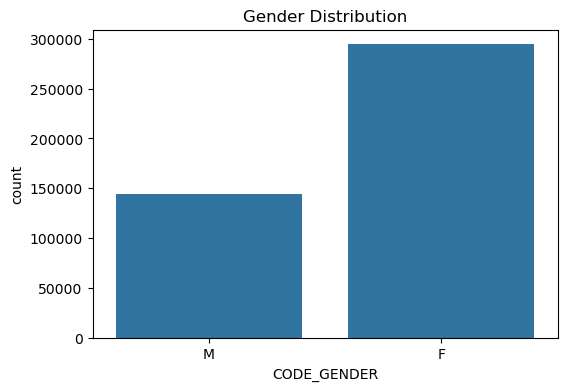

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='CODE_GENDER', data=application_df)
plt.title("Gender Distribution")
plt.show()

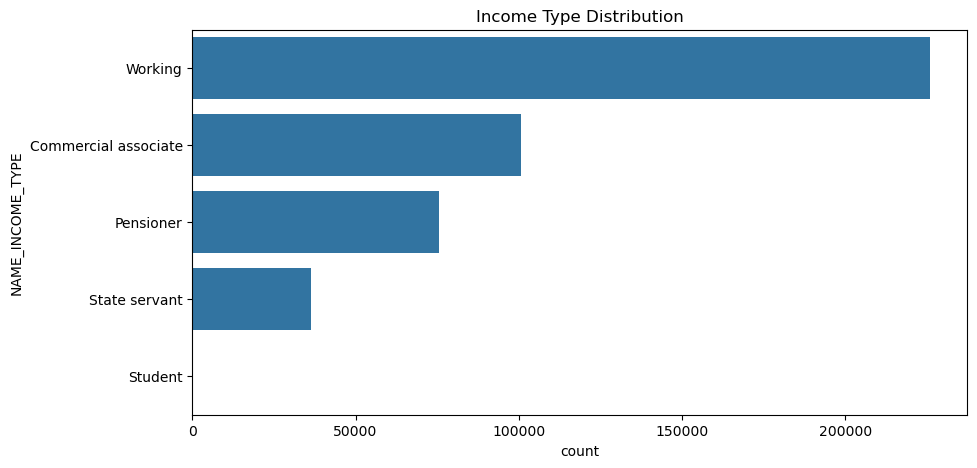

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(y='NAME_INCOME_TYPE', data=application_df)
plt.title("Income Type Distribution")
plt.show()

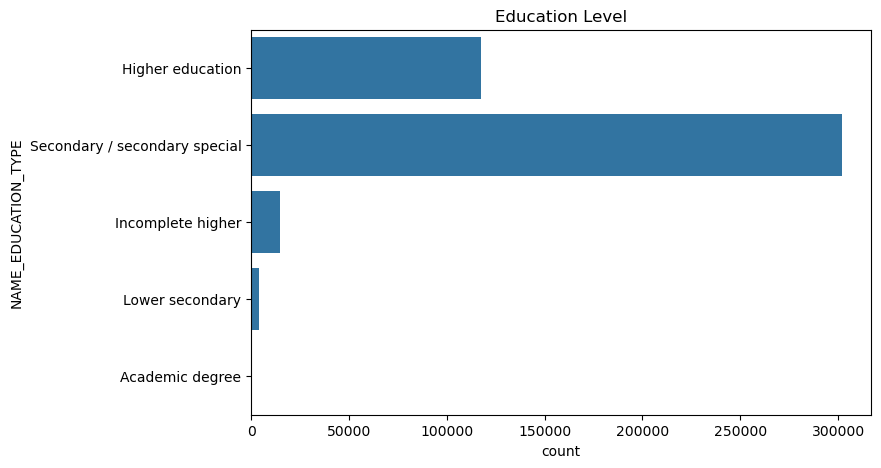

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(y='NAME_EDUCATION_TYPE', data=application_df)
plt.title("Education Level")
plt.show()

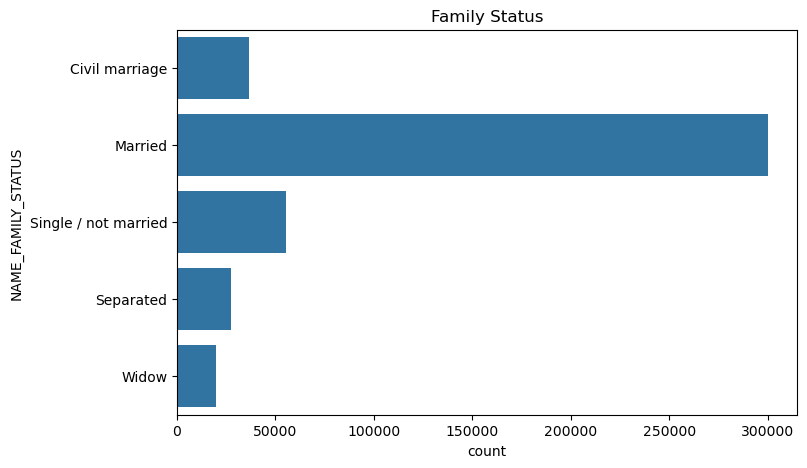

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(y='NAME_FAMILY_STATUS', data=application_df)
plt.title("Family Status")
plt.show()

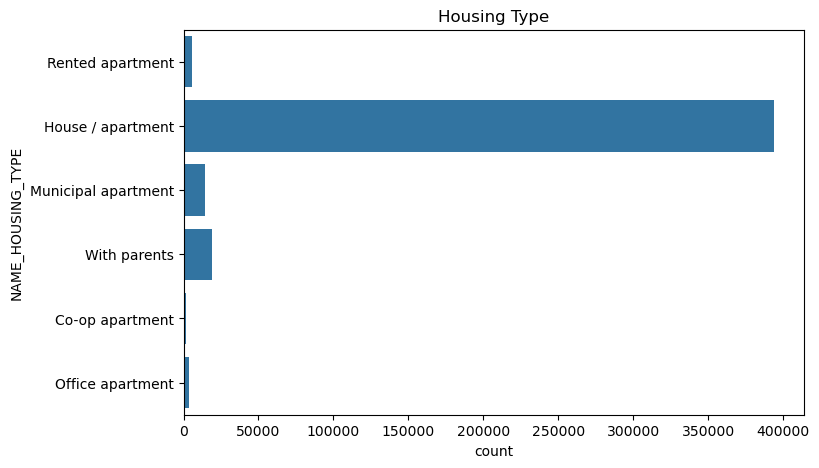

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(y='NAME_HOUSING_TYPE', data=application_df)
plt.title("Housing Type")
plt.show()

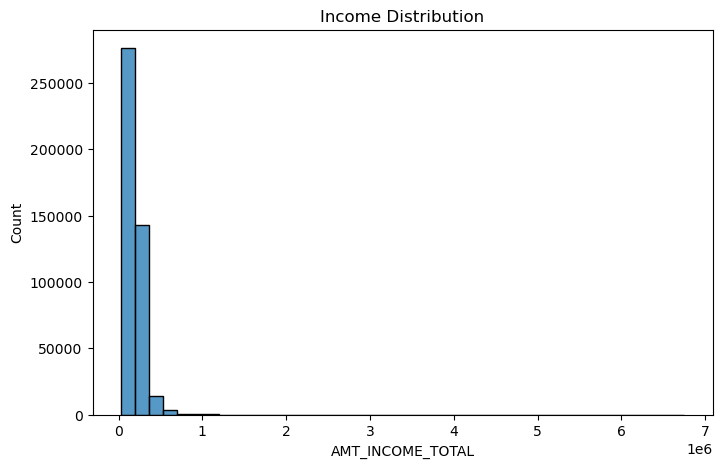

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(application_df['AMT_INCOME_TOTAL'], bins=40)
plt.title("Income Distribution")
plt.show()

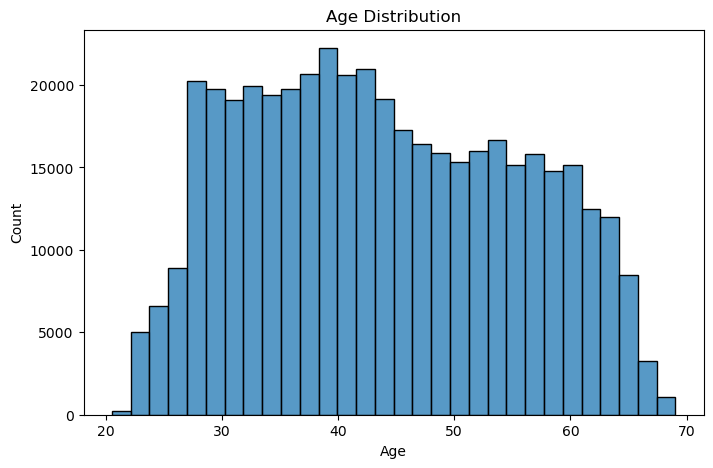

In [25]:
age = (-application_df['DAYS_BIRTH'])/365
plt.figure(figsize=(8,5))
sns.histplot(age, bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

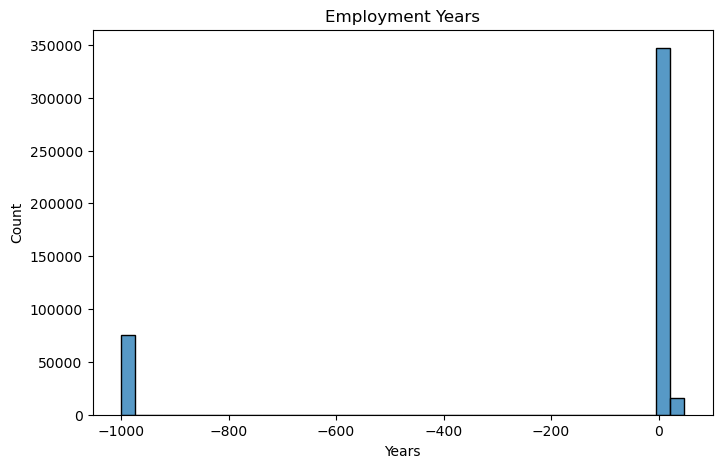

In [26]:
employment = (-application_df['DAYS_EMPLOYED'])/365
plt.figure(figsize=(8,5))
sns.histplot(employment, bins=40)
plt.title("Employment Years")
plt.xlabel("Years")
plt.show()

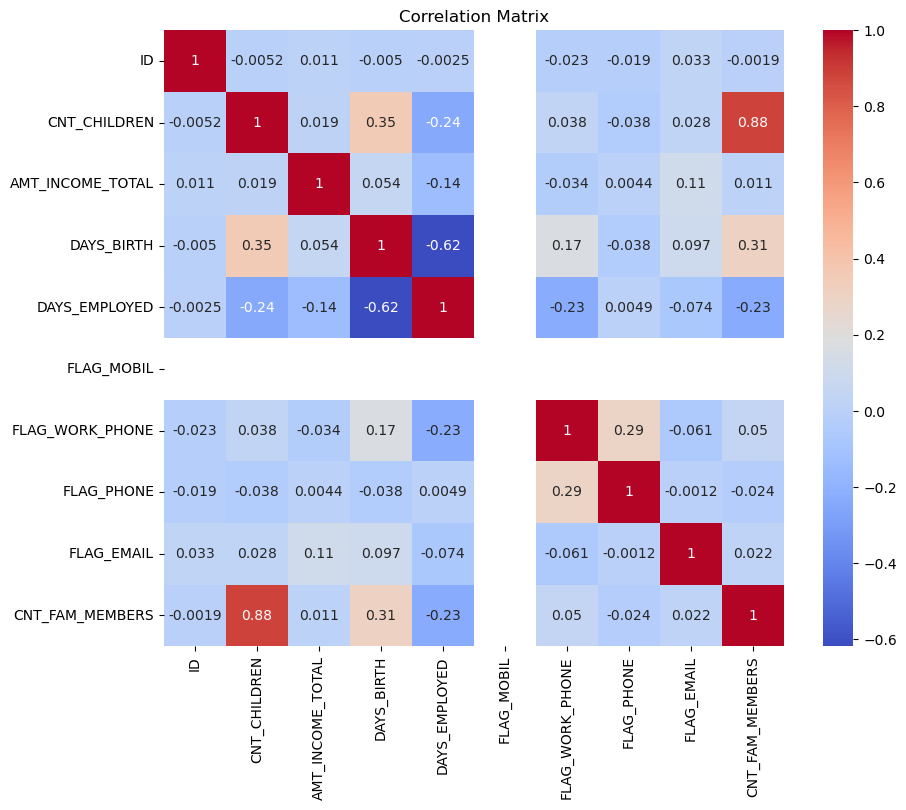

In [27]:
numeric_df = application_df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [28]:
application_df.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [29]:
missing_percentage = (application_df.isnull().sum() / len(application_df)) * 100
missing_percentage

ID                      0.000000
CODE_GENDER             0.000000
FLAG_OWN_CAR            0.000000
FLAG_OWN_REALTY         0.000000
CNT_CHILDREN            0.000000
AMT_INCOME_TOTAL        0.000000
NAME_INCOME_TYPE        0.000000
NAME_EDUCATION_TYPE     0.000000
NAME_FAMILY_STATUS      0.000000
NAME_HOUSING_TYPE       0.000000
DAYS_BIRTH              0.000000
DAYS_EMPLOYED           0.000000
FLAG_MOBIL              0.000000
FLAG_WORK_PHONE         0.000000
FLAG_PHONE              0.000000
FLAG_EMAIL              0.000000
OCCUPATION_TYPE        30.601039
CNT_FAM_MEMBERS         0.000000
dtype: float64

In [30]:
application_df['OCCUPATION_TYPE'] = application_df['OCCUPATION_TYPE'].fillna('Unknown')

In [31]:
application_df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
dtype: int64

In [32]:
(application_df['DAYS_EMPLOYED'] == 365243).sum()

np.int64(75329)

In [34]:
application_df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

In [35]:
application_df['DAYS_EMPLOYED'].fillna(application_df['DAYS_EMPLOYED'].median(), inplace=True)

In [36]:
application_df['DAYS_EMPLOYED'].isnull().sum()

np.int64(0)

In [37]:
application_df.duplicated(subset='ID').sum()

np.int64(47)

In [38]:
credit_df.duplicated(subset=['ID', 'MONTHS_BALANCE']).sum()

np.int64(0)

In [39]:
credit_df['STATUS'].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

In [40]:
credit_df['TARGET'] = credit_df['STATUS'].apply(
    lambda x: 0 if x in ['1', '2', '3', '4', '5'] else 1
)

In [41]:
credit_df['TARGET'].value_counts()

TARGET
1    1034381
0      14194
Name: count, dtype: int64

In [42]:
credit_target = credit_df.groupby('ID')['TARGET'].min().reset_index()

In [43]:
credit_target.head()

,ID,TARGET
0,5001711,1
1,5001712,1
2,5001713,1
3,5001714,1
4,5001715,1


In [44]:
final_df = application_df.merge(credit_target, on='ID', how='inner')

In [45]:
final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542.0,1,1,0,0,Unknown,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542.0,1,1,0,0,Unknown,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134.0,1,0,0,0,Security staff,2.0,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051.0,1,0,1,1,Sales staff,1.0,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051.0,1,0,1,1,Sales staff,1.0,1


In [46]:
print("Final Dataset Shape:", final_df.shape)

Final Dataset Shape: (36457, 19)


In [47]:
final_df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
dtype: int64

In [48]:
final_df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'TARGET'],
      dtype='object')

In [49]:
final_df.dtypes

ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED          float64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
TARGET                   int64
dtype: object

In [50]:
categorical_columns = final_df.select_dtypes(include='object').columns
print(categorical_columns)

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE'],
      dtype='object')


In [51]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in categorical_columns:
    final_df[column] = label_encoder.fit_transform(final_df[column])
print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


In [52]:
final_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,1,1,1,0,427500.0,4,1,0,4,-12005,-4542.0,1,1,0,0,17,2.0,0
1,5008805,1,1,1,0,427500.0,4,1,0,4,-12005,-4542.0,1,1,0,0,17,2.0,0
2,5008806,1,1,1,0,112500.0,4,4,1,1,-21474,-1134.0,1,0,0,0,16,2.0,1
3,5008808,0,0,1,0,270000.0,0,4,3,1,-19110,-3051.0,1,0,1,1,14,1.0,1
4,5008809,0,0,1,0,270000.0,0,4,3,1,-19110,-3051.0,1,0,1,1,14,1.0,1


In [53]:
final_df.dtypes

ID                       int64
CODE_GENDER              int64
FLAG_OWN_CAR             int64
FLAG_OWN_REALTY          int64
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE         int64
NAME_EDUCATION_TYPE      int64
NAME_FAMILY_STATUS       int64
NAME_HOUSING_TYPE        int64
DAYS_BIRTH               int64
DAYS_EMPLOYED          float64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE          int64
CNT_FAM_MEMBERS        float64
TARGET                   int64
dtype: object

In [54]:
final_df['TARGET'].value_counts()

TARGET
1    32166
0     4291
Name: count, dtype: int64

In [55]:
final_df.to_csv("cleaned_credit_card_data.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [56]:
# Separate Features and Target
X = final_df.drop('TARGET', axis=1)
y = final_df['TARGET']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (36457, 18)
Target Shape: (36457,)


In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (29165, 18)
Testing Data: (7292, 18)


In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature Scaling Completed!")

Feature Scaling Completed!


In [59]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [60]:
y_pred_log = log_model.predict(X_test_scaled)

In [61]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:",
      accuracy_score(y_test, y_pred_log))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8823368074602304

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       858
           1       0.88      1.00      0.94      6434

    accuracy                           0.88      7292
   macro avg       0.44      0.50      0.47      7292
weighted avg       0.78      0.88      0.83      7292



C:\Users\madis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\madis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\madis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [62]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [63]:
y_pred_dt = dt_model.predict(X_test)

In [64]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8561437191442677

Classification Report

              precision    recall  f1-score   support

           0       0.39      0.38      0.38       858
           1       0.92      0.92      0.92      6434

    accuracy                           0.86      7292
   macro avg       0.65      0.65      0.65      7292
weighted avg       0.85      0.86      0.86      7292



In [65]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [66]:
y_pred_rf = rf_model.predict(X_test)

In [67]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8678003291278114

Classification Report

              precision    recall  f1-score   support

           0       0.43      0.35      0.39       858
           1       0.92      0.94      0.93      6434

    accuracy                           0.87      7292
   macro avg       0.67      0.64      0.66      7292
weighted avg       0.86      0.87      0.86      7292



In [68]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [69]:
y_pred_xgb = xgb_model.predict(X_test)

In [70]:
print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8869994514536478

Classification Report

              precision    recall  f1-score   support

           0       0.59      0.12      0.21       858
           1       0.89      0.99      0.94      6434

    accuracy                           0.89      7292
   macro avg       0.74      0.56      0.57      7292
weighted avg       0.86      0.89      0.85      7292



In [71]:
import pickle

In [72]:
# Save the trained model
with open("credit_card_approval_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)
print("Model saved successfully!")

Model saved successfully!


In [73]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)
print("Scaler saved successfully!")

Scaler saved successfully!


In [74]:
with open("credit_card_approval_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)
print("Model loaded successfully!")

Model loaded successfully!


In [75]:
sample_prediction = loaded_model.predict(X_test.iloc[:5])
print("Sample Predictions:", sample_prediction)
print("Actual Values     :", y_test.iloc[:5].values)

Sample Predictions: [0 1 1 1 1]
Actual Values     : [0 1 0 1 1]


In [77]:
# Occupation Type Frequency
print(final_df['OCCUPATION_TYPE'].value_counts())

OCCUPATION_TYPE
17    11323
8      6211
3      3591
14     3485
10     3012
4      2138
6      1383
0      1241
11     1207
2       655
16      592
1       551
12      344
9       175
18      174
15      151
5        85
13       79
7        60
Name: count, dtype: int64


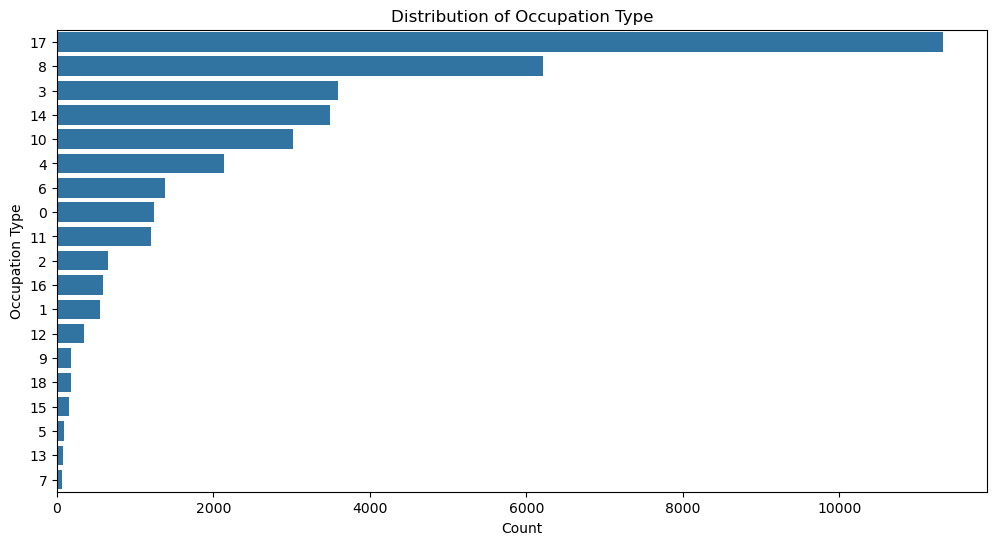

In [78]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=final_df,
    y='OCCUPATION_TYPE',
    order=final_df['OCCUPATION_TYPE'].value_counts().index
)
plt.title("Distribution of Occupation Type")
plt.xlabel("Count")
plt.ylabel("Occupation Type")
plt.show()

In [79]:
print(final_df['NAME_INCOME_TYPE'].value_counts())

NAME_INCOME_TYPE
4    18819
0     8490
1     6152
2     2985
3       11
Name: count, dtype: int64


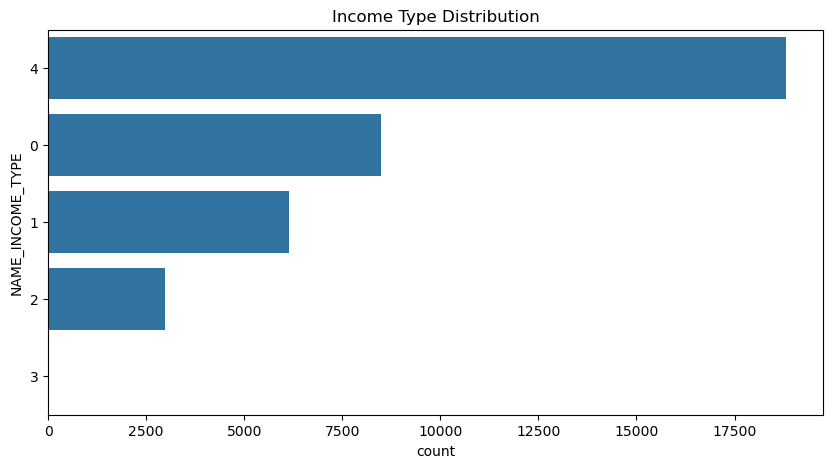

In [80]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=final_df,
    y='NAME_INCOME_TYPE',
    order=final_df['NAME_INCOME_TYPE'].value_counts().index
)
plt.title("Income Type Distribution")
plt.show()

In [81]:
print(final_df['NAME_EDUCATION_TYPE'].value_counts())

NAME_EDUCATION_TYPE
4    24777
1     9864
2     1410
3      374
0       32
Name: count, dtype: int64


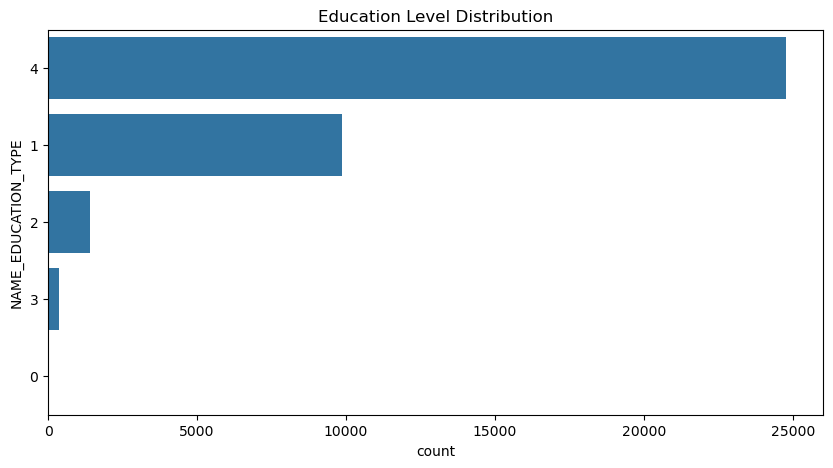

In [82]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=final_df,
    y='NAME_EDUCATION_TYPE',
    order=final_df['NAME_EDUCATION_TYPE'].value_counts().index
)
plt.title("Education Level Distribution")
plt.show()

In [83]:
print(final_df['NAME_FAMILY_STATUS'].value_counts())

NAME_FAMILY_STATUS
1    25048
3     4829
0     2945
2     2103
4     1532
Name: count, dtype: int64


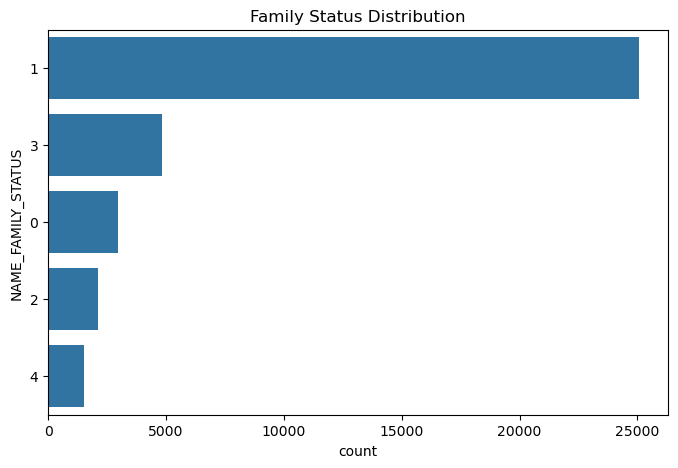

In [84]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=final_df,
    y='NAME_FAMILY_STATUS',
    order=final_df['NAME_FAMILY_STATUS'].value_counts().index
)
plt.title("Family Status Distribution")
plt.show()

In [85]:
print(final_df['NAME_HOUSING_TYPE'].value_counts())

NAME_HOUSING_TYPE
1    32548
5     1776
2     1128
4      575
3      262
0      168
Name: count, dtype: int64


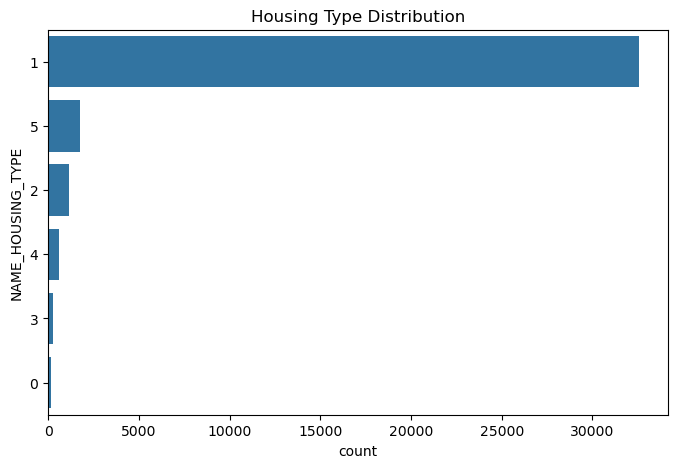

In [86]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=final_df,
    y='NAME_HOUSING_TYPE',
    order=final_df['NAME_HOUSING_TYPE'].value_counts().index
)
plt.title("Housing Type Distribution")
plt.show()

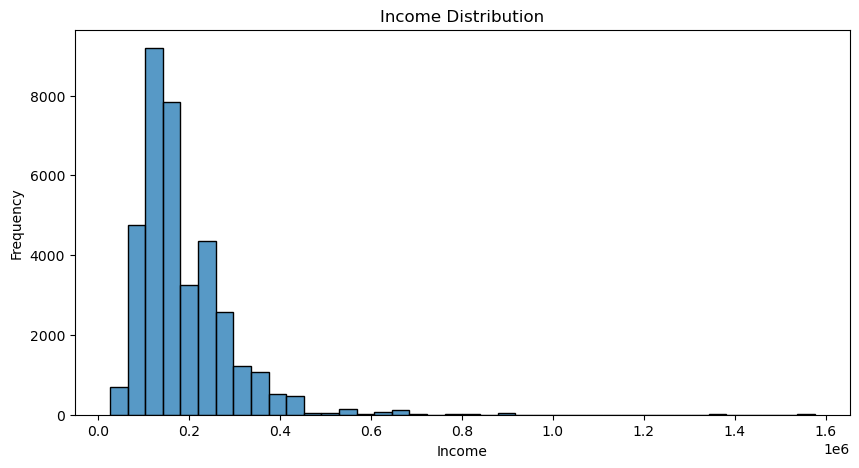

In [87]:
plt.figure(figsize=(10,5))
sns.histplot(final_df['AMT_INCOME_TOTAL'], bins=40)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

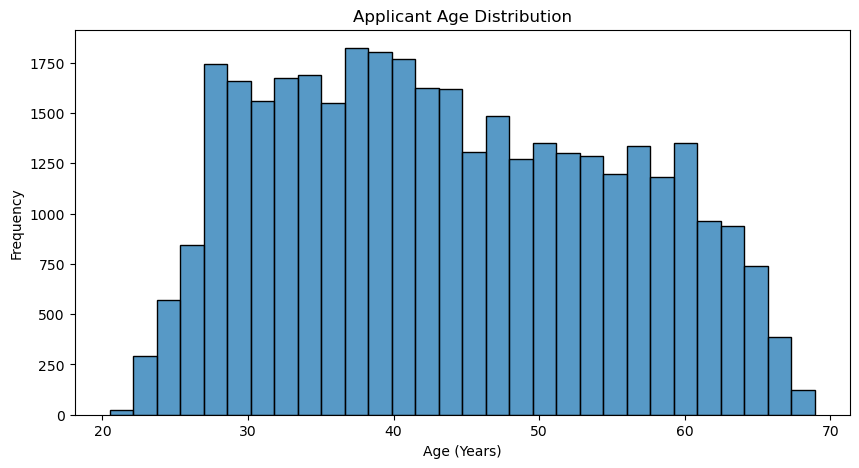

In [88]:
age = (-final_df['DAYS_BIRTH']) / 365
plt.figure(figsize=(10,5))
sns.histplot(age, bins=30)
plt.title("Applicant Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
plt.show()

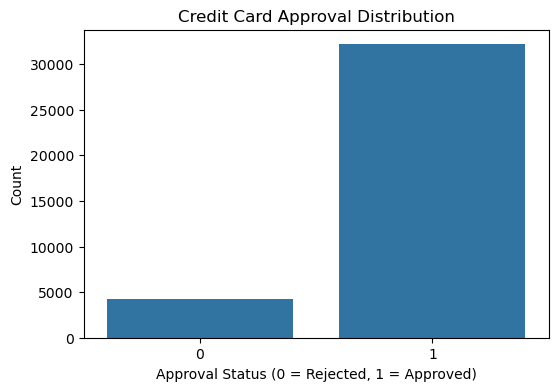

In [89]:
plt.figure(figsize=(6,4))
sns.countplot(data=final_df, x='TARGET')
plt.title("Credit Card Approval Distribution")
plt.xlabel("Approval Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Count")
plt.show()

In [90]:
# Correlation Matrix
correlation_matrix = final_df.corr()
correlation_matrix

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
ID,1.000000,0.012022,-0.011163,-0.098851,0.028878,-0.017667,0.023193,-0.009211,-0.004336,0.020613,0.056016,0.019039,NaN,0.079215,0.009879,-0.046979,-0.007483,0.026624,-0.003565
CODE_GENDER,0.012022,1.000000,0.361379,-0.050758,0.077690,0.197805,0.105639,0.005880,-0.099289,0.070301,0.202352,0.092882,NaN,0.064994,-0.026833,-0.003284,-0.126140,0.110782,-0.021257
FLAG_OWN_CAR,-0.011163,0.361379,1.000000,-0.015185,0.105839,0.215506,0.054817,-0.101272,-0.121716,0.016337,0.157144,0.045500,NaN,0.021644,-0.014019,0.021750,-0.117991,0.151814,0.010580
FLAG_OWN_REALTY,-0.098851,-0.050758,-0.015185,1.000000,-0.000575,0.032719,-0.046543,0.010997,0.022993,-0.179187,-0.129838,0.005821,NaN,-0.207732,-0.066601,0.052194,0.047487,-0.005723,0.027990
CNT_CHILDREN,0.028878,0.077690,0.105839,-0.000575,1.000000,0.033691,0.109401,-0.049823,-0.160386,0.023302,0.339357,0.029152,NaN,0.048091,-0.016291,0.015960,-0.129652,0.889114,-0.011525
AMT_INCOME_TOTAL,-0.017667,0.197805,0.215506,0.032719,0.033691,1.000000,-0.072974,-0.226931,-0.001191,-0.006480,0.067908,-0.039249,NaN,-0.037746,0.017245,0.086681,-0.088027,0.023750,-0.024202
NAME_INCOME_TYPE,0.023193,0.105639,0.054817,-0.046543,0.109401,-0.072974,1.000000,0.057225,-0.048532,0.035694,0.213509,-0.090271,NaN,0.165785,0.006529,-0.019567,-0.197472,0.109313,0.007346
NAME_EDUCATION_TYPE,-0.009211,0.005880,-0.101272,0.010997,-0.049823,-0.226931,0.057225,1.000000,0.007747,-0.036322,-0.169024,-0.022834,NaN,-0.021092,-0.044875,-0.098457,0.083796,-0.041344,0.003237
NAME_FAMILY_STATUS,-0.004336,-0.099289,-0.121716,0.022993,-0.160386,-0.001191,-0.048532,0.007747,1.000000,0.010025,-0.106486,0.014679,NaN,-0.063103,-0.015065,-0.010895,0.052968,-0.546511,-0.001017
NAME_HOUSING_TYPE,0.020613,0.070301,0.016337,-0.179187,0.023302,-0.006480,0.035694,-0.036322,0.010025,1.000000,0.211562,0.060033,NaN,0.030080,-0.020254,0.012879,-0.064402,0.003805,-0.013072


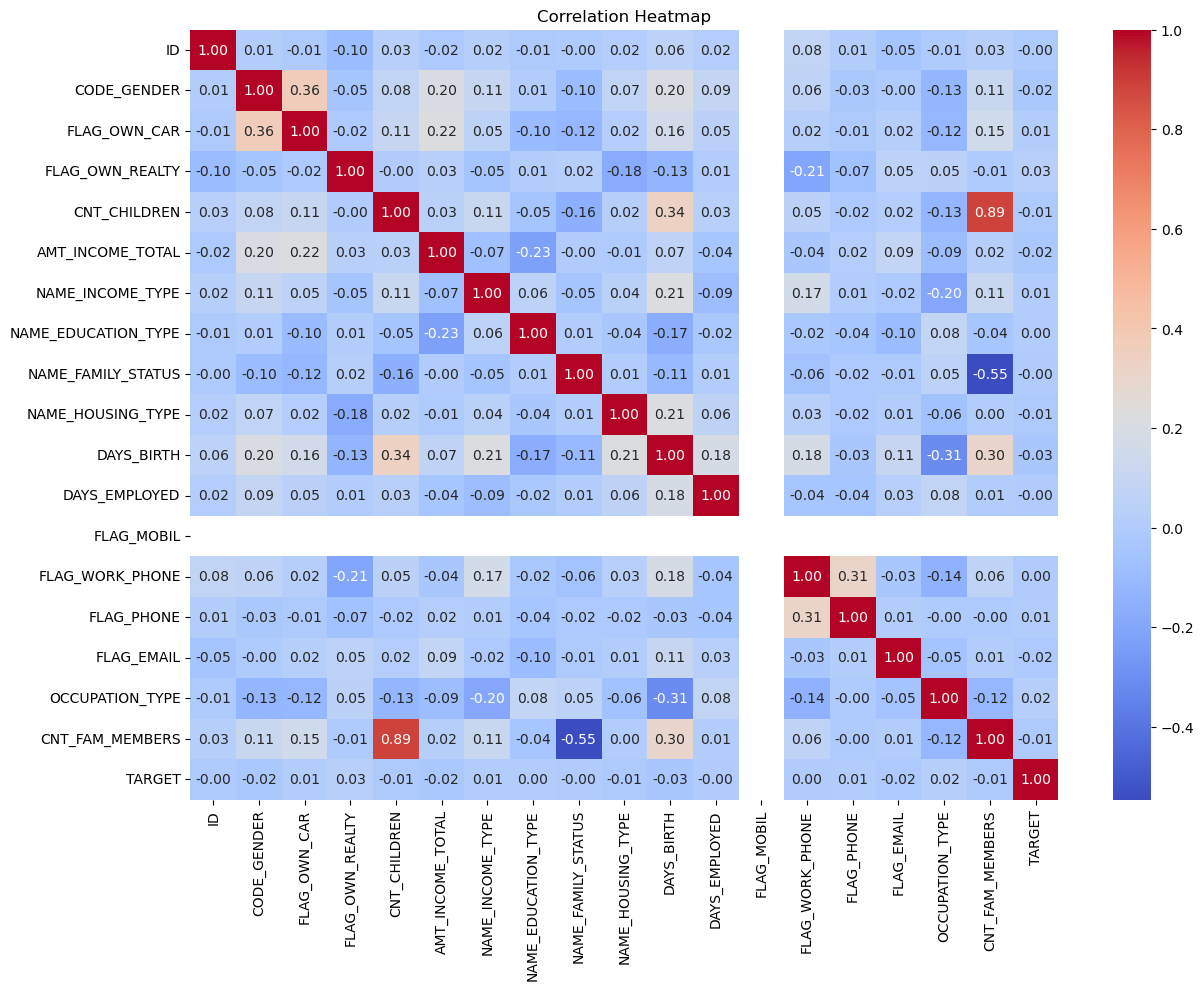

In [91]:
plt.figure(figsize=(14,10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

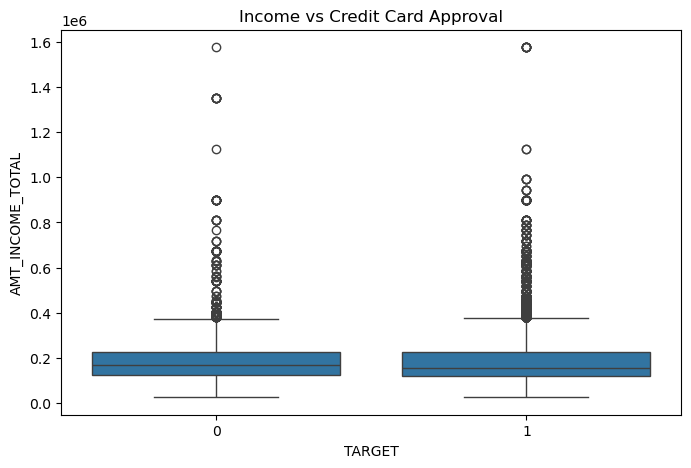

In [92]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='TARGET',
    y='AMT_INCOME_TOTAL',
    data=final_df
)
plt.title("Income vs Credit Card Approval")
plt.show()

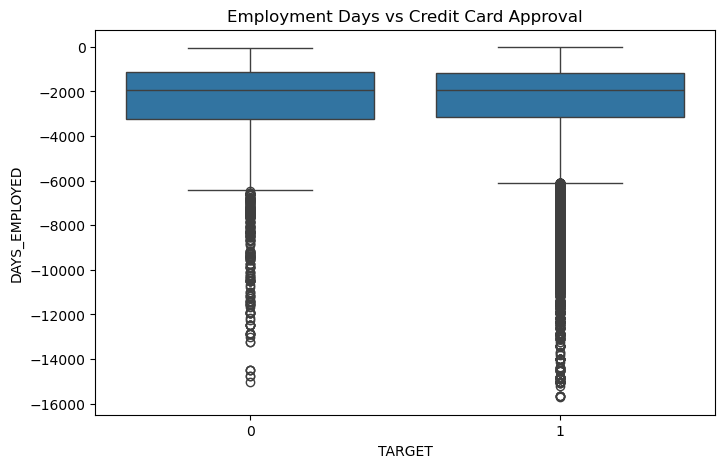

In [93]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='TARGET',
    y='DAYS_EMPLOYED',
    data=final_df
)
plt.title("Employment Days vs Credit Card Approval")
plt.show()

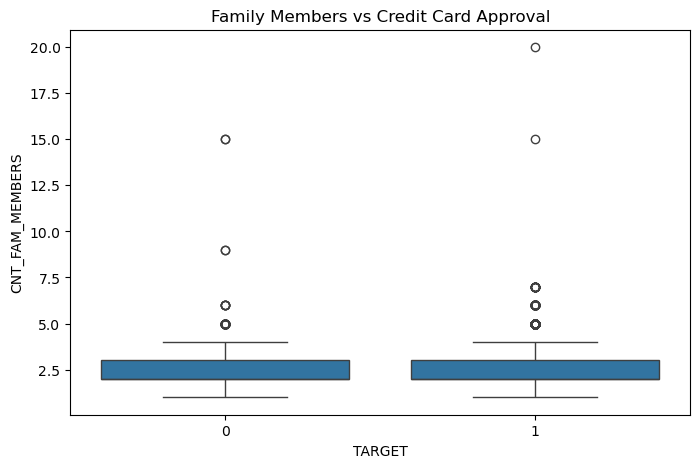

In [94]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='TARGET',
    y='CNT_FAM_MEMBERS',
    data=final_df
)
plt.title("Family Members vs Credit Card Approval")
plt.show()

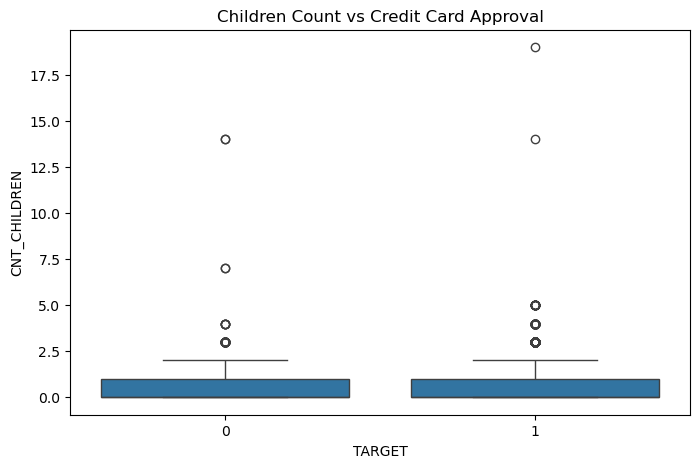

In [95]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='TARGET',
    y='CNT_CHILDREN',
    data=final_df
)
plt.title("Children Count vs Credit Card Approval")
plt.show()

In [96]:
final_df['AGE'] = (-final_df['DAYS_BIRTH']) / 365

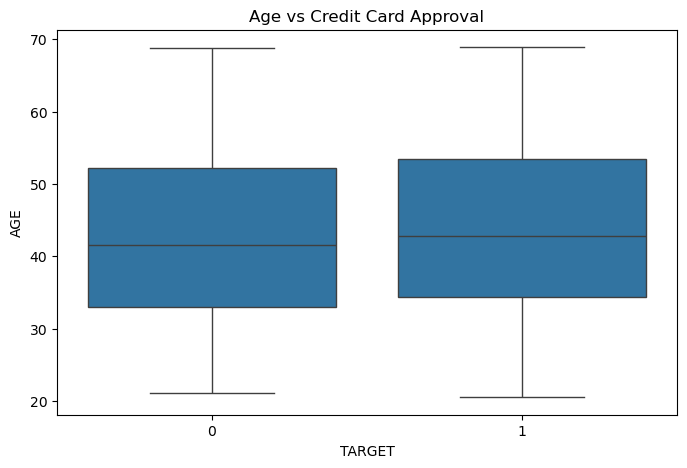

In [97]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='TARGET',
    y='AGE',
    data=final_df
)
plt.title("Age vs Credit Card Approval")
plt.show()

In [99]:
final_df['AGE'] = (-final_df['DAYS_BIRTH']) / 365

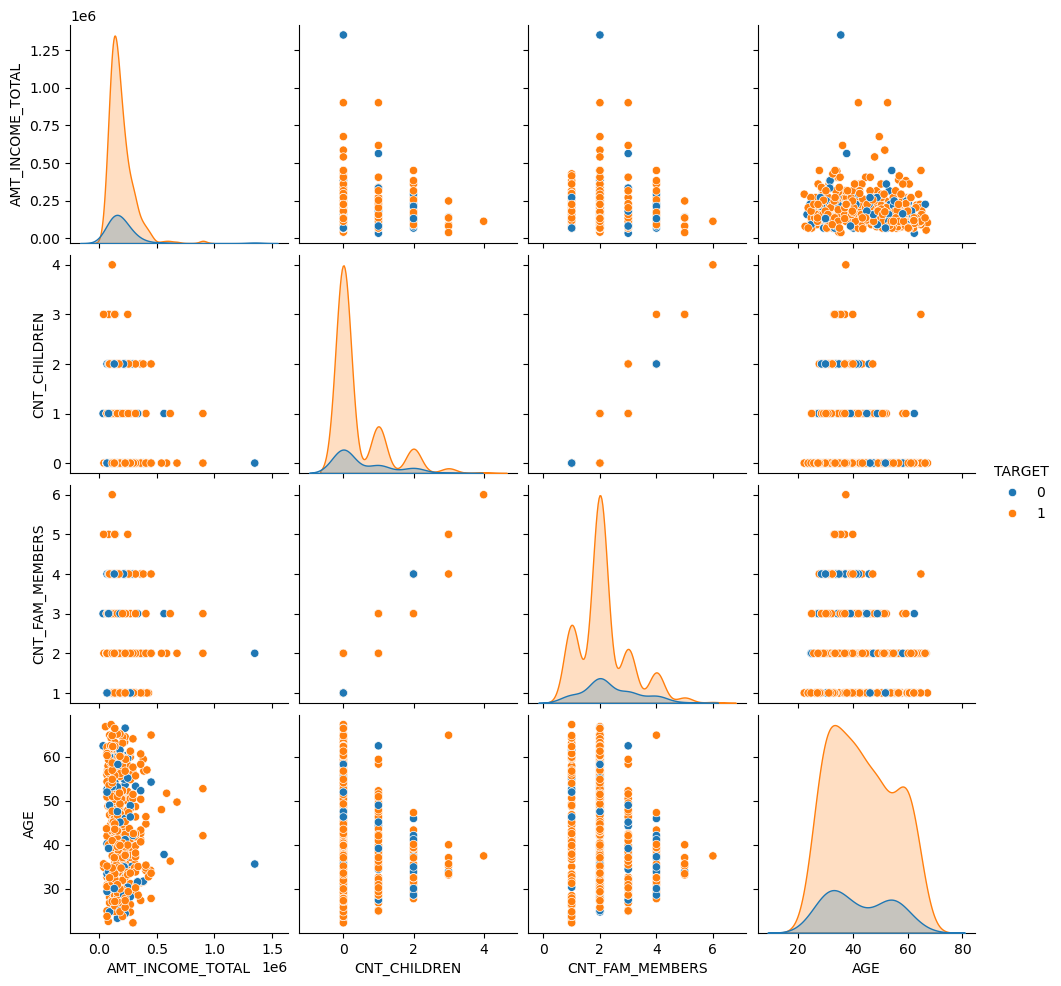

In [100]:
sample_df = final_df.sample(500, random_state=42)
sns.pairplot(
    sample_df,
    vars=[
        'AMT_INCOME_TOTAL',
        'CNT_CHILDREN',
        'CNT_FAM_MEMBERS',
        'AGE'
    ],
    hue='TARGET'
)
plt.show()

In [101]:
# Descriptive Statistics
final_df.describe()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE
count,3.645700e+04,36457.000000,36457.000000,36457.000000,36457.000000,3.645700e+04,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.0,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000
mean,5.078227e+06,0.329895,0.379708,0.672189,0.430315,1.866857e+05,2.398195,3.097183,1.367885,1.282881,-15975.173382,-2524.088735,1.0,0.225526,0.294813,0.089722,10.595880,2.198453,0.882300,43.767598
std,4.187524e+04,0.470181,0.485321,0.469422,0.742367,1.017892e+05,1.734032,1.341292,0.954557,0.951675,4200.549944,2166.797230,0.0,0.417934,0.455965,0.285787,5.617823,0.911686,0.322257,11.508356
min,5.008804e+06,0.000000,0.000000,0.000000,0.000000,2.700000e+04,0.000000,0.000000,0.000000,0.000000,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,20.517808
25%,5.042028e+06,0.000000,0.000000,0.000000,0.000000,1.215000e+05,1.000000,1.000000,1.000000,1.000000,-19438.000000,-3153.000000,1.0,0.000000,0.000000,0.000000,6.000000,2.000000,1.000000,34.142466
50%,5.074614e+06,0.000000,0.000000,1.000000,0.000000,1.575000e+05,4.000000,4.000000,1.000000,1.000000,-15563.000000,-1924.000000,1.0,0.000000,0.000000,0.000000,10.000000,2.000000,1.000000,42.638356
75%,5.115396e+06,1.000000,1.000000,1.000000,1.000000,2.250000e+05,4.000000,4.000000,1.000000,1.000000,-12462.000000,-1169.000000,1.0,0.000000,1.000000,0.000000,17.000000,3.000000,1.000000,53.254795
max,5.150487e+06,1.000000,1.000000,1.000000,19.000000,1.575000e+06,4.000000,4.000000,4.000000,5.000000,-7489.000000,-17.000000,1.0,1.000000,1.000000,1.000000,18.000000,20.000000,1.000000,68.909589


In [102]:
final_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,36457.0,5.078227e+06,41875.240788,5.008804e+06,5.042028e+06,5.074614e+06,5.115396e+06,5.150487e+06
CODE_GENDER,36457.0,3.298955e-01,0.470181,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
FLAG_OWN_CAR,36457.0,3.797076e-01,0.485321,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
FLAG_OWN_REALTY,36457.0,6.721892e-01,0.469422,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
CNT_CHILDREN,36457.0,4.303152e-01,0.742367,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,36457.0,1.866857e+05,101789.226482,2.700000e+04,1.215000e+05,1.575000e+05,2.250000e+05,1.575000e+06
NAME_INCOME_TYPE,36457.0,2.398195e+00,1.734032,0.000000e+00,1.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00
NAME_EDUCATION_TYPE,36457.0,3.097183e+00,1.341292,0.000000e+00,1.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00
NAME_FAMILY_STATUS,36457.0,1.367885e+00,0.954557,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
NAME_HOUSING_TYPE,36457.0,1.282881e+00,0.951675,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00


In [103]:
final_df.describe(include='all')

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE
count,3.645700e+04,36457.000000,36457.000000,36457.000000,36457.000000,3.645700e+04,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.0,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000
mean,5.078227e+06,0.329895,0.379708,0.672189,0.430315,1.866857e+05,2.398195,3.097183,1.367885,1.282881,-15975.173382,-2524.088735,1.0,0.225526,0.294813,0.089722,10.595880,2.198453,0.882300,43.767598
std,4.187524e+04,0.470181,0.485321,0.469422,0.742367,1.017892e+05,1.734032,1.341292,0.954557,0.951675,4200.549944,2166.797230,0.0,0.417934,0.455965,0.285787,5.617823,0.911686,0.322257,11.508356
min,5.008804e+06,0.000000,0.000000,0.000000,0.000000,2.700000e+04,0.000000,0.000000,0.000000,0.000000,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,20.517808
25%,5.042028e+06,0.000000,0.000000,0.000000,0.000000,1.215000e+05,1.000000,1.000000,1.000000,1.000000,-19438.000000,-3153.000000,1.0,0.000000,0.000000,0.000000,6.000000,2.000000,1.000000,34.142466
50%,5.074614e+06,0.000000,0.000000,1.000000,0.000000,1.575000e+05,4.000000,4.000000,1.000000,1.000000,-15563.000000,-1924.000000,1.0,0.000000,0.000000,0.000000,10.000000,2.000000,1.000000,42.638356
75%,5.115396e+06,1.000000,1.000000,1.000000,1.000000,2.250000e+05,4.000000,4.000000,1.000000,1.000000,-12462.000000,-1169.000000,1.0,0.000000,1.000000,0.000000,17.000000,3.000000,1.000000,53.254795
max,5.150487e+06,1.000000,1.000000,1.000000,19.000000,1.575000e+06,4.000000,4.000000,4.000000,5.000000,-7489.000000,-17.000000,1.0,1.000000,1.000000,1.000000,18.000000,20.000000,1.000000,68.909589


In [104]:
final_df.dtypes

ID                       int64
CODE_GENDER              int64
FLAG_OWN_CAR             int64
FLAG_OWN_REALTY          int64
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE         int64
NAME_EDUCATION_TYPE      int64
NAME_FAMILY_STATUS       int64
NAME_HOUSING_TYPE        int64
DAYS_BIRTH               int64
DAYS_EMPLOYED          float64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE          int64
CNT_FAM_MEMBERS        float64
TARGET                   int64
AGE                    float64
dtype: object

In [105]:
final_df.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
AGE                    0
dtype: int64

In [106]:
print("Duplicate Rows :", final_df.duplicated().sum())

Duplicate Rows : 0


In [107]:
final_df.nunique()

ID                     36457
CODE_GENDER                2
FLAG_OWN_CAR               2
FLAG_OWN_REALTY            2
CNT_CHILDREN               9
AMT_INCOME_TOTAL         265
NAME_INCOME_TYPE           5
NAME_EDUCATION_TYPE        5
NAME_FAMILY_STATUS         5
NAME_HOUSING_TYPE          6
DAYS_BIRTH              7183
DAYS_EMPLOYED           3640
FLAG_MOBIL                 1
FLAG_WORK_PHONE            2
FLAG_PHONE                 2
FLAG_EMAIL                 2
OCCUPATION_TYPE           19
CNT_FAM_MEMBERS           10
TARGET                     2
AGE                     7183
dtype: int64

In [108]:
print("Rows :", final_df.shape[0])
print("Columns :", final_df.shape[1])

Rows : 36457
Columns : 20


In [109]:
# Convert negative values into positive values
application_df['DAYS_BIRTH'] = application_df['DAYS_BIRTH'].abs()
application_df['DAYS_EMPLOYED'] = application_df['DAYS_EMPLOYED'].abs()
print("Negative values converted successfully!")

Negative values converted successfully!


In [110]:
credit_features = credit_df.groupby('ID').agg(
    open_month=('MONTHS_BALANCE', 'min'),
    end_month=('MONTHS_BALANCE', 'max')
).reset_index()

credit_features['window'] = (
    credit_features['end_month']
    - credit_features['open_month']
)
credit_features.head()

,ID,open_month,end_month,window
0,5001711,-3,0,3
1,5001712,-18,0,18
2,5001713,-21,0,21
3,5001714,-14,0,14
4,5001715,-59,0,59


In [111]:
application_df = application_df.merge(
    credit_features,
    on='ID',
    how='left'
)

application_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,open_month,end_month,window
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,4542.0,1,1,0,0,Unknown,2.0,-15.0,0.0,15.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,4542.0,1,1,0,0,Unknown,2.0,-14.0,0.0,14.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,1134.0,1,0,0,0,Security staff,2.0,-29.0,0.0,29.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,3051.0,1,0,1,1,Sales staff,1.0,-4.0,0.0,4.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,3051.0,1,0,1,1,Sales staff,1.0,-26.0,-22.0,4.0


In [112]:
application_df[
    ['ID', 'open_month', 'end_month', 'window']
].head()

,ID,open_month,end_month,window
0,5008804,-15.0,0.0,15.0
1,5008805,-14.0,0.0,14.0
2,5008806,-29.0,0.0,29.0
3,5008808,-4.0,0.0,4.0
4,5008809,-26.0,-22.0,4.0


In [113]:
application_df['TOTAL_DEPENDENTS'] = (
    application_df['CNT_CHILDREN']
    + application_df['CNT_FAM_MEMBERS']
)
application_df[
    ['CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'TOTAL_DEPENDENTS']
].head()

,CNT_CHILDREN,CNT_FAM_MEMBERS,TOTAL_DEPENDENTS
0,0,2.0,2.0
1,0,2.0,2.0
2,0,2.0,2.0
3,0,1.0,1.0
4,0,1.0,1.0


In [114]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_log)
print(cm)

[[   0  858]
 [   0 6434]]


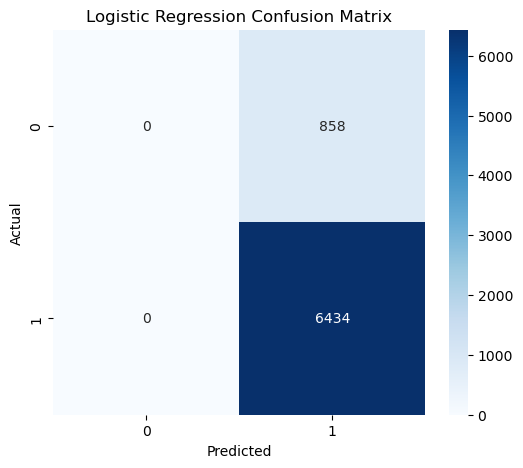

In [115]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [116]:
from sklearn.metrics import confusion_matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[ 302  556]
 [ 408 6026]]


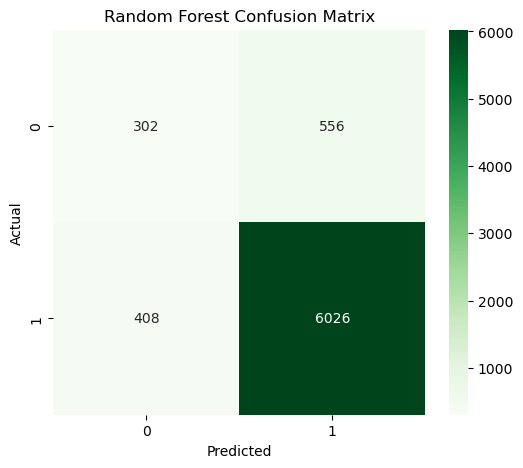

In [117]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [118]:
from sklearn.metrics import confusion_matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[ 324  534]
 [ 515 5919]]


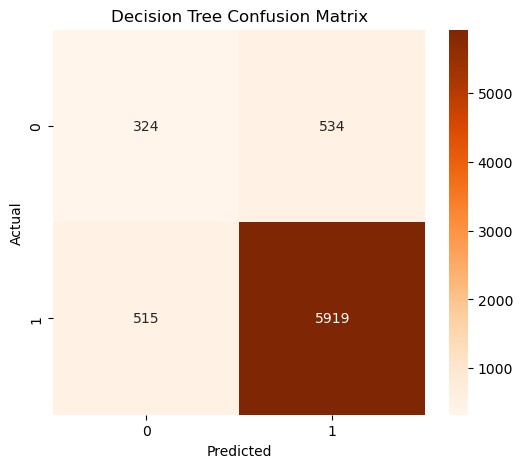

In [119]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Oranges'
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()